In [1]:
import numpy as np

import matplotlib.pyplot as plt

import h5py as hf

from dataclasses import dataclass

import glob

In [2]:
@dataclass
class Measurement:
    data: np.ndarray
    uncertainty: np.ndarray

@dataclass
class Experiment:
    
    # Model parameters
    width: int
    depth: int
    loss_fn: str
        
    # Loss attributes
    test_loss: Measurement
    test_accuracy: Measurement
    train_loss: Measurement
    train_accuracy: Measurement
        
    # Collective Variables
    entropy: Measurement
    trace: Measurement
    

In [3]:
def _extract_database_data(recorder_path: str, full: bool = True):
    """
    Helper function for populating an experiment class.
    """
    with hf.File(recorder_path, "r") as db:
        loss = db["loss"][:]
        accuracy = db["accuracy"][:]
                
        if full:
            trace = db["trace"][:]
            entropy = db["entropy"][:]
    
    if full:
        return loss, accuracy, entropy, trace
    else:
        return loss, accuracy
            
        

def load_loss_experiment(file_path) -> list:
    """
    Load the data from one loss experiment in.
    """
    depth_directories = glob.glob(f"{file_path}/*")  # All depth paths
    experiment_data = []  # To be returned
    
    # Loop over the depths
    for depth_dir in depth_directories:
        width_directories = glob.glob(f"{depth_dir}/*")
        
        # Loop over the widths
        for width_dir in width_directories:
            recorder_paths = glob.glob(f"{width_dir}/*")
            
            # Split test and train.
            test_recorders = [
                item for item in recorder_paths if item.split("/")[-1].split("_")[0] == "test"
            ]
            train_recorders = [
                item for item in recorder_paths if item.split("/")[-1].split("_")[0] == "train" 
            ]
            
            # Process the test data
            raw_test_loss = []
            raw_test_accuracy = []
            for recorder in test_recorders:
                loss, accuracy = _extract_database_data(recorder, full=False)
                raw_test_loss.append(loss)
                raw_test_accuracy.append(accuracy)
            
            # Final test values for data class
            test_loss = Measurement(
                data=np.mean(raw_test_loss, axis=0),
                uncertainty=np.std(raw_test_loss, axis=0)
            )
            test_accuracy = Measurement(
                data=np.mean(raw_test_accuracy, axis=0),
                uncertainty=np.std(raw_test_accuracy, axis=0)
            )
            
            # Process the train data
            raw_train_loss = []
            raw_train_accuracy = []
            raw_train_entropy = []
            raw_train_trace = []
            for recorder in train_recorders:
                loss, accuracy, entropy, trace = _extract_database_data(recorder, full=True)
                
                raw_train_loss.append(loss)
                raw_train_accuracy.append(accuracy)
                raw_train_entropy.append(entropy)
                raw_train_trace.append(trace)
                
            # Final train values for data class
            train_loss = Measurement(
                data=np.mean(raw_train_loss, axis=0),
                uncertainty=np.std(raw_train_loss, axis=0)
            )
            train_accuracy = Measurement(
                data=np.mean(raw_train_accuracy, axis=0),
                uncertainty=np.std(raw_train_accuracy, axis=0)
            )
            entropy = Measurement(
                data=np.mean(raw_train_entropy, axis=0),
                uncertainty=np.std(raw_train_entropy, axis=0)
            )
            trace = Measurement(
                data=np.mean(raw_train_trace, axis=0),
                uncertainty=np.std(raw_train_trace, axis=0)
            )
            
            # Create final experiment dataclass
            experiment_data.append(
                Experiment(
                    width=width_dir.split("/")[-1],
                    depth=depth_dir.split("/")[-1],
                    loss_fn=file_path,
                    test_loss=test_loss,
                    test_accuracy=test_accuracy,
                    train_loss=train_loss,
                    train_accuracy=train_accuracy,
                    entropy=entropy,
                    trace=trace
                )
            )
            

    return experiment_data
            


In [4]:
mptwo = load_loss_experiment("MeanPowerLoss2")
mpfour = load_loss_experiment("MeanPowerLoss4")
mpsix = load_loss_experiment("MeanPowerLoss6")

In [5]:
single_depth = [item for item in mptwo if item.width=='256']

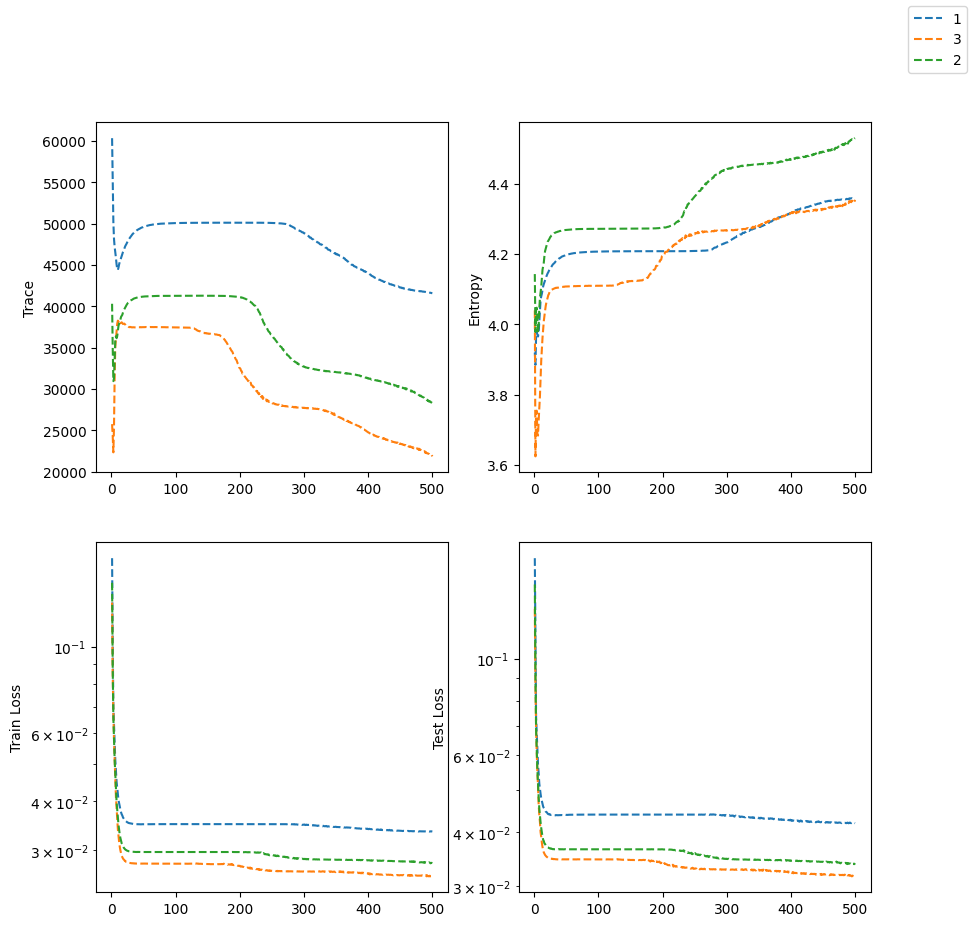

In [8]:
epochs = np.linspace(1, 500, 500)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for item in single_depth:
    ax[0, 0].errorbar(
        epochs, 
        item.trace.data, 
#         yerr = item.trace.uncertainty,
#         capsize=10,
#         marker='.',
        ls="--",
        label=item.depth
    )
    ax[0, 1].errorbar(
        epochs, 
        item.entropy.data, 
#         yerr = item.entropy.uncertainty,
#         capsize=10,
#         marker='.',
        ls="--",
#         label=item.width
    )
    ax[1, 0].errorbar(
        epochs, 
        item.train_loss.data, 
#         yerr = item.entropy.uncertainty,
#         capsize=10,
#         marker='.',
        ls="--",
#         label=item.width
    )
    ax[1, 1].errorbar(
        epochs, 
        item.test_loss.data, 
#         yerr = item.entropy.uncertainty,
#         capsize=10,
#         marker='.',
        ls="--",
#         label=item.width
    )
    

ax[0, 0].set_ylabel("Trace")
ax[0, 1].set_ylabel("Entropy")
ax[1, 0].set_ylabel("Train Loss")
ax[1, 1].set_ylabel("Test Loss")

ax[1, 0].set_yscale("log")
ax[1, 1].set_yscale("log")

fig.legend()
plt.show()